#ML4Net - Lab 2

## Team members

Marc Rodríguez (267283) | Christopher Matienzo (251417) | Isaac Pérez (268275) | Daniel Yearwood (268690)

## Description

In this lab, you will implement an ML model that detects congestion in Wi-Fi networks. In particular, you will desing and implement a supervised learning model (e.g., linear regression, multi-layer perceptron, neural network), which you will train using a dataset that was generated using the ns-3 simulator.

Each row in the dataset is organized as (x1, x2, ..., x26, y1, y2, ..., y26, s, r, l), where:

* `x1, x2..., x26, y1, y2, ..., y26` represent the histogram of the Inter-Frame Space (IFS) values for M frames that accessed the medium in a 60 seconds observation sample.
  * `x26` represents the maximum IFS duration (in ms) in the considered M frames whereas `x1` is `x26`/26
  * The remaining `xi` values are buckets at uniform spacing between `x1` and `x26`.
  * For i>1, the values of `yi` represent the IFS histogram count (in percentage) for a corresponding bucket interval between `xi`-1 and `xi`.
  * In the case of `y1`, the bucket interval is between 0 and `x1`
* `s` is the average IFS duration (in ms)
* `r` is the percentage of frame collisions
* `l` is the label, where 1 indicates that the network is saturated, and 0, that it is not

Original dataset: https://ieee-dataport.org/documents/dataset-identification-saturated-and-unsaturated-wi-fi-networks

## Instructions

*   Follow the steps from this Notebook and complete the proposed exercises.
*   Deliver the completed Notebook by uploading it to your Github repository.
*   Submission deadline: 01 Juny 2025 (EoB).

## Setting up the environment

1. Connect your Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


2. Download the dataset

In [ ]:
#!wget https://github.com/fwilhelmi/fwilhelmi.github.io/raw/refs/heads/master/files/dataset_Lab2.zip

3. Define the main path of the code

In [ ]:
mypath="/content/drive/Shareddrives/MLNETWORKS/LABS/LAB2"

4. Extract the source code to the destination folder

In [ ]:
#mkdir $mypath; cp dataset_Lab2.zip $mypath; cd $mypath; unzip dataset_Lab2.zip

## Visualizing the data




In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    log_loss
)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

       0       1       2       3       4       5       6       7       8   \
0  0.0065  0.0130  0.0195  0.0260  0.0325  0.0390  0.0455  0.0520  0.0585   
1  0.0263  0.0526  0.0789  0.1052  0.1316  0.1579  0.1842  0.2105  0.2368   
2  0.0176  0.0352  0.0528  0.0704  0.0881  0.1057  0.1233  0.1409  0.1585   
3  0.0222  0.0444  0.0666  0.0888  0.1110  0.1332  0.1554  0.1776  0.1998   
4  0.0189  0.0379  0.0568  0.0758  0.0947  0.1137  0.1326  0.1516  0.1705   

       9   ...      45      46      47      48      49      50      51  \
0  0.0650  ...  0.0316  0.0368  0.0312  0.0000  0.0316  0.0364  0.0304   
1  0.2631  ...  0.0316  0.0368  0.0312  0.0000  0.0316  0.0364  0.0304   
2  0.1761  ...  0.0316  0.0368  0.0312  0.0312  0.0316  0.0299  0.0304   
3  0.2220  ...  0.0316  0.0307  0.0312  0.0000  0.0360  0.0364  0.0304   
4  0.1895  ...  0.0316  0.0368  0.0312  0.0000  0.0316  0.0364  0.0304   

       52      53  54  
0  0.0604  0.9960   1  
1  0.0604  0.9960   1  
2  0.0604  0.9957   

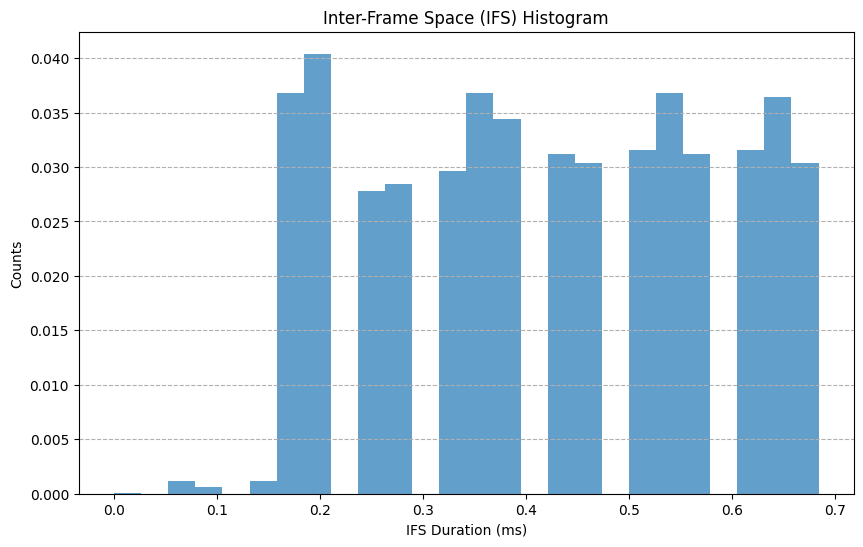

In [ ]:
def plot_ifs_histogram(data_row):
    """
    Plots the Inter-Frame Space (IFS) histogram from a single row of the dataset.

    Args:
        data_row (list or numpy.ndarray): A list or array representing a single row
                                          in the format (x1, ..., x26, y1, ..., y26, s, r, l).
    """

    # Get IFS values and the corresponding counts
    x_values = np.array(data_row[:26])
    y_counts = np.array(data_row[26:52])

    # Calculate the bin edges based on x_values
    bin_edges = [0] + list(x_values)

    # Create the histogram plot
    plt.figure(figsize=(10, 6))
    plt.bar(bin_edges[:-1], y_counts, width=np.diff(bin_edges)[0], align='edge', alpha=0.7)

    # Add labels and title
    plt.xlabel("IFS Duration (ms)")
    plt.ylabel("Counts")
    plt.title("Inter-Frame Space (IFS) Histogram")
    plt.grid(axis='y', linestyle='--')

    # Show the plot
    plt.show()

# Example usage

# -> Read the data file
file_name = mypath + '/train_data.csv'
train_data_df = pd.read_csv(file_name, header=None)
print(train_data_df.head())

# -> Get a sample from the dataset and plot it
row_index = 1
sample_data = train_data_df.iloc[row_index].values
plot_ifs_histogram(sample_data)

## EXERCISES

### Exercise 1:
Define an approach for training and validating the model you are going to train with the proposed data. Then, perform the split accordingly.

In [ ]:
# We load the train and test sets
train_df = pd.read_csv(mypath + '/train_data.csv', header=None)
test_df = pd.read_csv(mypath + '/test_data.csv', header=None)

In [ ]:
# We divide the features and labels for the datasets
X_train = train_df.iloc[:, :-1]
y_train = train_df.iloc[:, -1]
X_test = test_df.iloc[:, :-1]
y_test = test_df.iloc[:, -1]

# And we divide the training into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [ ]:
# Sizes of the features
X_train.shape, X_val.shape, X_test.shape

((16000, 54), (4000, 54), (500, 54))

In [ ]:
# Reset of the row indexes
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

X_val = X_val.reset_index(drop=True)
y_val = y_val.reset_index(drop=True)

In [ ]:
# Plot of the training features
X_train.head()

,0,1,2,3,4,5,6,7,8,9,...,44,45,46,47,48,49,50,51,52,53
0,0.0397,0.0795,0.1192,0.1589,0.1987,0.2384,0.2781,0.3179,0.3576,0.3973,...,0.0003,0.0000,0.0052,0.0001,0.0008,0.0004,0.0008,0.0004,0.0453,0.7913
1,0.0302,0.0603,0.0905,0.1206,0.1508,0.1809,0.2111,0.2412,0.2714,0.3015,...,0.0052,0.0000,0.0028,0.0008,0.0000,0.0004,0.0000,0.0004,0.0459,0.7336
2,0.0430,0.0859,0.1289,0.1718,0.2148,0.2578,0.3007,0.3437,0.3866,0.4296,...,0.0124,0.0176,0.0064,0.0080,0.0012,0.0001,0.0004,0.0020,0.0450,0.7086
3,0.0272,0.0544,0.0815,0.1087,0.1359,0.1631,0.1903,0.2174,0.2446,0.2718,...,0.0044,0.0020,0.0008,0.0000,0.0004,0.0004,0.0000,0.0004,0.0453,0.7853
4,0.1383,0.2765,0.4148,0.5530,0.6913,0.8295,0.9678,1.1060,1.2443,1.3825,...,0.0000,0.0004,0.0000,0.0025,0.0000,0.0000,0.0018,0.0025,0.0590,0.9621


In [ ]:
# Plot of the training labels
y_train.head()

,54
0,1
1,1
2,1
3,1
4,1


### Exercise 2:

Define your ML model, so that it can be called for training and test. Examples of approaches that you could use (but not limited to):

*   Logistic Regression
*   K-Nearest Neighbors (KNN)
*   Decision Trees or Random Forests
*   Convolutional Neural Network (CNN)

In [ ]:
# We define a K-Nearest Neighbors model
knn_model = KNeighborsClassifier(n_neighbors=5)

### Exercise 3:

Define the hyperparameters that you will use to train the model.

In [ ]:
# We define the hyperparameters of the model
knn_model = KNeighborsClassifier(
    n_neighbors=5,          # Number of neighbors to consider
    weights='uniform',      # The way to weight the neighbors, can be 'uniform' o 'distance'
    algorithm='auto',       # The algorithm to search for nearest neighbors, with 'auto' sklearn chooses
    leaf_size=30,           # Size of the leaves (used depending on the algorithm chosen)
    p=2                     # Distance used, could be 1=Manhattan, 2=Euclidian
)

### Exercise 4:
Train the model and show the procedure (e.g., evolution of the training/validation loss).

# **KNN**

In [ ]:
neighbors_list = [1, 3, 5, 7, 9, 11, 13, 15]  # Trying with different number of neighbors

# Arrays to compare the performance
loss_train = []
loss_val = []
acc_train = []
acc_val = []

# Defining the model
for n_neighbors in neighbors_list:
    knn_model = KNeighborsClassifier(
        n_neighbors=n_neighbors,
        weights='uniform',
        algorithm='auto',
        leaf_size=30,
        p=2
    )
    # And training it
    knn_model.fit(X_train, y_train)

    # Predictions and probabilities
    y_train_pred = knn_model.predict(X_train)
    y_val_pred = knn_model.predict(X_val)

    y_train_proba = knn_model.predict_proba(X_train)
    y_val_proba = knn_model.predict_proba(X_val)

    # Metrics to monitor performance
    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc = accuracy_score(y_val, y_val_pred)

    train_logloss = log_loss(y_train, y_train_proba)
    val_logloss = log_loss(y_val, y_val_proba)

    acc_train.append(train_acc)
    acc_val.append(val_acc)
    loss_train.append(train_logloss)
    loss_val.append(val_logloss)

    # Print the results
    print(f"Neighbors: {n_neighbors} | "
          f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | "
          f"Train LogLoss: {train_logloss:.4f} | Val LogLoss: {val_logloss:.4f}")

Neighbors: 1 | Train Acc: 1.0000 | Val Acc: 0.9755 | Train LogLoss: 0.0000 | Val LogLoss: 0.8831
Neighbors: 3 | Train Acc: 0.9864 | Val Acc: 0.9695 | Train LogLoss: 0.0288 | Val LogLoss: 0.3190
Neighbors: 5 | Train Acc: 0.9809 | Val Acc: 0.9720 | Train LogLoss: 0.0425 | Val LogLoss: 0.1892
Neighbors: 7 | Train Acc: 0.9768 | Val Acc: 0.9698 | Train LogLoss: 0.0528 | Val LogLoss: 0.1702
Neighbors: 9 | Train Acc: 0.9736 | Val Acc: 0.9675 | Train LogLoss: 0.0608 | Val LogLoss: 0.1589
Neighbors: 11 | Train Acc: 0.9711 | Val Acc: 0.9657 | Train LogLoss: 0.0670 | Val LogLoss: 0.1639
Neighbors: 13 | Train Acc: 0.9686 | Val Acc: 0.9637 | Train LogLoss: 0.0724 | Val LogLoss: 0.1596
Neighbors: 15 | Train Acc: 0.9668 | Val Acc: 0.9630 | Train LogLoss: 0.0769 | Val LogLoss: 0.1542


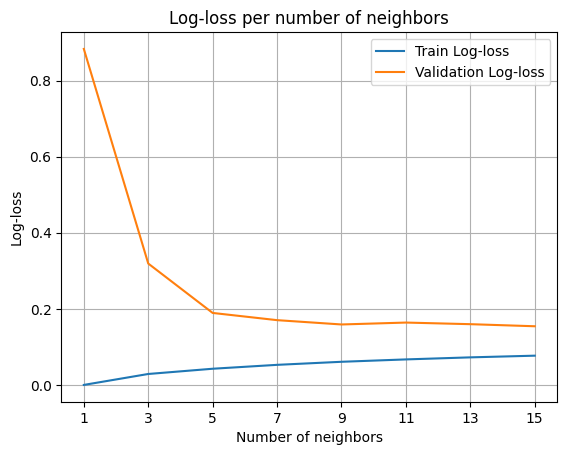

In [ ]:
# We plot the loss curves
neighbor_labels = [str(n) for n in neighbors_list]

plt.plot(neighbor_labels, loss_train, label="Train Log-loss")
plt.plot(neighbor_labels, loss_val, label="Validation Log-loss")
plt.title("Log-loss per number of neighbors")
plt.xlabel("Number of neighbors")
plt.ylabel("Log-loss")
plt.legend()
plt.grid(True)
plt.show()

The train log-loss (blue) increases lightly while the number of neighbors (k)increase. However, validation log-loss decreases fastly between k=1 and k=5, and then it is stabilized.

Then, in k=5 we can find the best trade-off between training and validation log-losses.

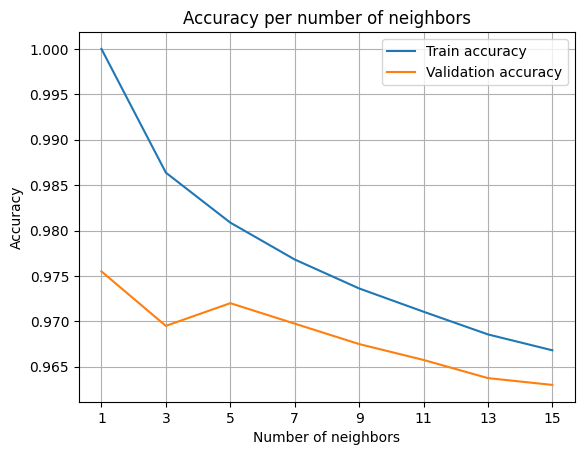

In [ ]:
# We plot the accuracy curves
neighbor_labels = [str(n) for n in neighbors_list]

plt.plot(neighbor_labels, acc_train, label="Train accuracy")
plt.plot(neighbor_labels, acc_val, label="Validation accuracy")
plt.title("Accuracy per number of neighbors")
plt.xlabel("Number of neighbors")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

The train accuracy (blue) decreases when the number of neighbors (k) increases. This is due to the overfitting, since  in k=1 the model is memorizing the model the training data. When k increases, the model becomes more general, and this yields to a decreasing accuracy in training set.

The validation accuracy (orange) starts high with k=1, decreases for k=3, improves at k=5 and then starts decreasing until the end. This suggest that in k=5 the model has more generalization.

In conclusion, the results of both metrics suggest that the **best value** for the number of neighbors is **k=5**

In [ ]:
# We train the definitive model
knn_model = KNeighborsClassifier(
  n_neighbors=5,
  weights='uniform',
  algorithm='auto',
  leaf_size=30,
  p=2
  )
knn_model.fit(X_train, y_train)

KNeighborsClassifier()

### Exercise 5:

Select and define the most appropriate evaluation metric(s). Discuss the appropriateness of your evaluation metrics for the binary classification problem we are considering.

               MODEL EVALUATION              
Accuracy       : 0.9720
Precision      : 0.9818
Recall         : 0.9623
F1-score       : 0.9720
AUC - ROC      : 0.9936
--------------------------------------------------
Confusion Matrix:
 True Negatives: 1946
 False Positives: 36
 False Negatives: 76
 True Positives: 1942
--------------------------------------------------
Classification Report (per class):
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1982
           1       0.98      0.96      0.97      2018

    accuracy                           0.97      4000
   macro avg       0.97      0.97      0.97      4000
weighted avg       0.97      0.97      0.97      4000



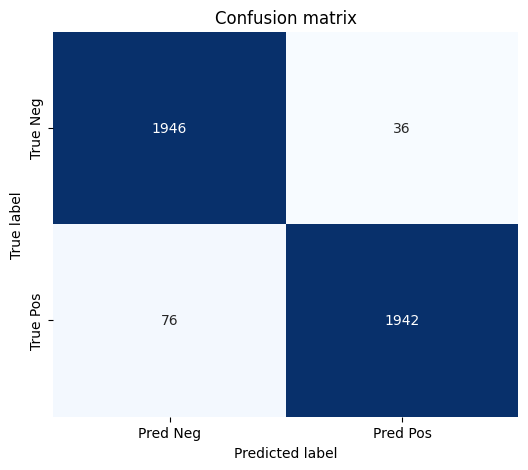

In [ ]:
# Predictions and probabilities in validation
y_val_pred = knn_model.predict(X_val)
y_val_proba = knn_model.predict_proba(X_val)[:, 1]

# Defining the metrics to evaluate
accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)
auc = roc_auc_score(y_val, y_val_proba)

# Confusion matrix
cm = confusion_matrix(y_val, y_val_pred)
tn, fp, fn, tp = cm.ravel()

# Evaluation report
print("="*50)
print("               MODEL EVALUATION              ")
print("="*50)
print(f"Accuracy       : {accuracy:.4f}")
print(f"Precision      : {precision:.4f}")
print(f"Recall         : {recall:.4f}")
print(f"F1-score       : {f1:.4f}")
print(f"AUC - ROC      : {auc:.4f}")
print("-"*50)
print(f"Confusion Matrix:")
print(f" True Negatives: {tn}")
print(f" False Positives: {fp}")
print(f" False Negatives: {fn}")
print(f" True Positives: {tp}")
print("-"*50)
print("Classification Report (per class):")
print(classification_report(y_val, y_val_pred))
print("="*50)

# Confusion matrix visualization
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred Neg','Pred Pos'],
            yticklabels=['True Neg','True Pos'])
plt.title('Confusion matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()


For this binary classification problem, we have chosen the following evaluation metrics: accuracy, precision, recall, F1-score and AUC-ROC for the model in general; a confusion matrix to know the predicted labels compared to the real ones; and a classification report per class where we have the precision, the recall and the f1-score.

The results obtained on the training set show solid performance of the binary classification model. Accuracy is 97.20%, indicating a high percentage of overall correct answers, although this metric alone can be limited if there is class imbalance, which is not the case here. Precision, at 98.18%, reflects that almost all of the model's positive predictions were correct, while recall, at 96.23%, indicates that the model correctly identified most of the true positive cases. Both are key indicators when seeking to minimize Type I and II errors. The F1 score, which combines precision and recall, also reaches 97.20%, confirming a good balance between the two metrics. Finally, the AUC-ROC, with a value of 0.9936, shows the model's excellent ability to discriminate between positive and negative classes at different thresholds. Together, these metrics allow us to conclude that the model has very robust behavior on the training set, with the F1-score and AUC-ROC being the most appropriate metrics to evaluate its performance in this context.



### Exercise 6:

Evaluate your trained model on the test set, using the evaluation metrics that you have proposed. Remember that the test data should have not been seen by the model, so that we can properly estimate of its generalization capabilities.

             FINAL EVALUATION ON TEST               
Accuracy       : 0.9140
Precision      : 0.8581
Recall         : 1.0000
F1-score       : 0.9236
AUC - ROC      : 0.9812
--------------------------------------------------
Confusion Matrix:
 True Negatives: 197
 False Positives: 43
 False Negatives: 0
 True Positives: 260
--------------------------------------------------
Classification Report (per class):
              precision    recall  f1-score   support

           0       1.00      0.82      0.90       240
           1       0.86      1.00      0.92       260

    accuracy                           0.91       500
   macro avg       0.93      0.91      0.91       500
weighted avg       0.93      0.91      0.91       500



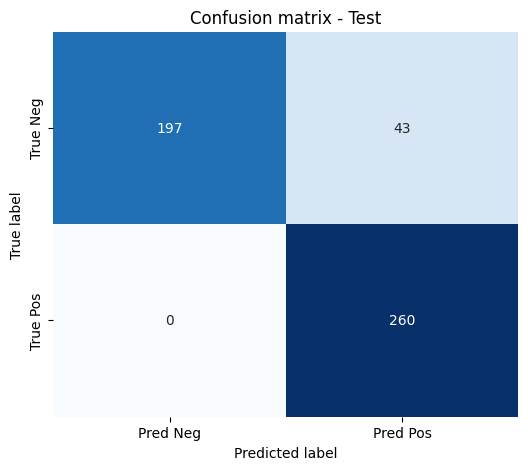

In [ ]:
# Predictions and probabilities in validation
y_test_pred = knn_model.predict(X_test)
y_test_proba = knn_model.predict_proba(X_test)[:, 1]

# Defining the metrics to evaluate
accuracy_test = accuracy_score(y_test, y_test_pred)
precision_test = precision_score(y_test, y_test_pred)
recall_test = recall_score(y_test, y_test_pred)
f1_test = f1_score(y_test, y_test_pred)
auc_test = roc_auc_score(y_test, y_test_proba)

# Confusion matrix
cm_test = confusion_matrix(y_test, y_test_pred)
tn, fp, fn, tp = cm_test.ravel()

# Evaluation report
print("="*50)
print("             FINAL EVALUATION ON TEST               ")
print("="*50)
print(f"Accuracy       : {accuracy_test:.4f}")
print(f"Precision      : {precision_test:.4f}")
print(f"Recall         : {recall_test:.4f}")
print(f"F1-score       : {f1_test:.4f}")
print(f"AUC - ROC      : {auc_test:.4f}")
print("-"*50)
print(f"Confusion Matrix:")
print(f" True Negatives: {tn}")
print(f" False Positives: {fp}")
print(f" False Negatives: {fn}")
print(f" True Positives: {tp}")
print("-"*50)
print("Classification Report (per class):")
print(classification_report(y_test, y_test_pred))
print("="*50)

# Confusion matrix visualization
plt.figure(figsize=(6,5))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred Neg','Pred Pos'],
            yticklabels=['True Neg','True Pos'])
plt.title('Confusion matrix - Test')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()


On the test set, the model maintains high performance, although more moderate compared to the training set. Accuracy reaches 91.40%, indicating a good proportion of correct predictions overall. Precision, at 85.81%, shows that a considerable percentage of positive predictions were correct, although there is a significant number of false positives. In contrast, recall is perfect at 100%, meaning that the model correctly detected all true positive cases. The F1 score, which represents the balance between precision and recall, stands at 92.36%, confirming good overall performance. Furthermore, the AUC-ROC, with a value of 0.9812, indicates that the model continues to have an excellent ability to distinguish between classes, even at different thresholds. In summary, the model shows very competitive behavior in the test set, being especially strong in the detection of positive cases, which reinforces the choice of the F1-score and the AUC-ROC as the most appropriate metrics to evaluate its overall performance.